Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [2]:
indexes = np.arange(1940,2011,10)
json_files = [f'movies-{i}s.json' for i in indexes]
json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/"
dataframes = []

2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [3]:
for file in json_files:
    
    file_path = json_dir + file

    try:
        df = pd.read_json(file_path)
    except Exception as e:
        print (f'Could not read {file_path}: {e}')

    drop_colamns = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

    df = df.drop(columns = drop_colamns, errors = 'ignore')

    df = df.dropna()

    dataframes.append(df)

combined = pd.concat(dataframes, ignore_index = True)

In [4]:
combined

,title,year,cast,genres
0,20 Mule Team,1940,"[Wallace Beery, Leo Carrillo, Marjorie Rambeau...",[Western]
1,Abe Lincoln in Illinois,1940,"[Raymond Massey, Gene Lockhart, Ruth Gordon]","[Biography, Drama, Historical]"
2,Adventure in Diamonds,1940,"[George Brent, Isa Miranda, John Loder]","[Drama, Crime]"
3,Alias the Deacon,1940,"[Bob Burns, Mischa Auer, Peggy Moran]",[Comedy]
4,"All This, and Heaven Too",1940,"[Bette Davis, Charles Boyer, Jeffrey Lynn]",[Drama]
...,...,...,...,...
20927,Spies in Disguise,2019,"[Will Smith, Tom Holland, Rashida Jones, Ben M...","[Animated, Comedy, Spy]"
20928,Little Women,2019,"[Saoirse Ronan, Emma Watson, Florence Pugh, El...","[Drama, Historical]"
20929,1917,2019,"[George MacKay, Dean-Charles Chapman, Mark Str...",[War]
20930,Just Mercy,2019,"[Michael B. Jordan, Jamie Foxx, Brie Larson, R...","[Drama, Legal, Biography]"


3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [5]:
combined.to_csv('combined.csv', index = False)

print('Shape: ', combined.shape)

df = combined

Shape:  (20932, 4)


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20932 entries, 0 to 20931
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   20932 non-null  object
 1   year    20932 non-null  int64 
 2   cast    20932 non-null  object
 3   genres  20932 non-null  object
dtypes: int64(1), object(3)
memory usage: 654.3+ KB


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

In [7]:
df['genres'] = df['genres'].apply(lambda x: [x] if isinstance(x, str) else x)

df_exploded = df.explode('genres')

df_exploded = df_exploded[df_exploded['genres'].notna()]

genre_counts = df_exploded['genres'].value_counts()\
    .reset_index()\
    .sort_values(by='count', ascending=False)

genre_counts.columns = ['genres', 'movies_count']

genre_counts

,genres,movies_count
0,Drama,6385
1,Comedy,6326
2,Western,2362
3,Action,1750
4,Crime,1738
5,Thriller,1700
6,Romance,1634
7,Horror,1507
8,Musical,1258
9,Adventure,1165


In [8]:
print('\ Top 10 genres:')
print(genre_counts.head(10))

\ Top 10 genres:
      genres  movies_count
0      Drama          6385
1     Comedy          6326
2    Western          2362
3     Action          1750
4      Crime          1738
5   Thriller          1700
6    Romance          1634
7     Horror          1507
8    Musical          1258
9  Adventure          1165


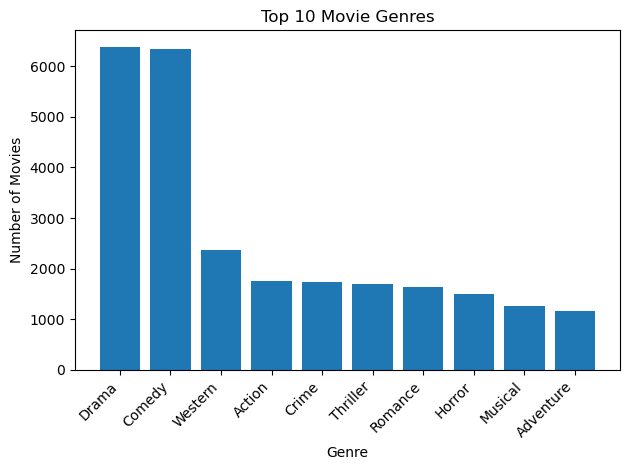

In [13]:
top_10_genres = genre_counts.head(10)
plt.bar(top_10_genres['genres'], top_10_genres['movies_count'])
plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

Text(0.5, 1.0, 'Shape of Top Genres')

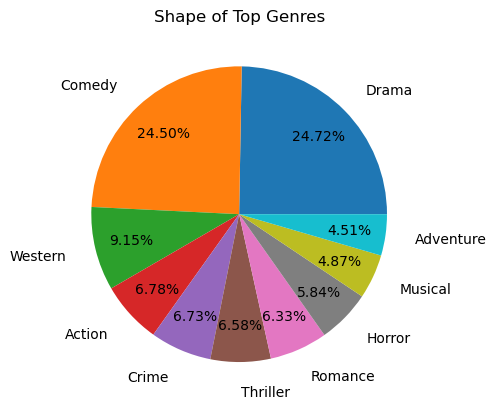

In [18]:
plt.pie(x=top_10_genres['movies_count'], labels=top_10_genres['genres'], autopct="%.2f%%", pctdistance = 0.75, labeldistance = 1.2)
plt.title('Shape of Top Genres')

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [21]:
top_3_genres = top_10_genres.head(3)

print("Вибрані жанри:")
print(top_3_genres, "\n")

Вибрані жанри:
    genres  movies_count
0    Drama          6385
1   Comedy          6326
2  Western          2362 



In [24]:
df_top_genres = df_exploded[df_exploded['genres'].isin(['Drama','Comedy','Western'])]

trend = df_top_genres.groupby(['year','genres']).size().reset_index(name = 'movies_count')

print('Тренд по роках:')
print(trend.head(), "\n")

Тренд по роках:
   year   genres  movies_count
0  1940   Comedy           152
1  1940    Drama           140
2  1940  Western           131
3  1941   Comedy           198
4  1941    Drama           102 



In [25]:
trend_pivot = trend.pivot(index = 'year', columns = 'genres', values = 'movies_count')

print('Pivot-таблиця:')
print(trend_pivot.head(), "\n")

Pivot-таблиця:
genres  Comedy  Drama  Western
year                          
1940     152.0  140.0    131.0
1941     198.0  102.0    123.0
1942     160.0  119.0    112.0
1943     137.0   72.0     99.0
1944     144.0   88.0     94.0 



<Axes: xlabel='year'>

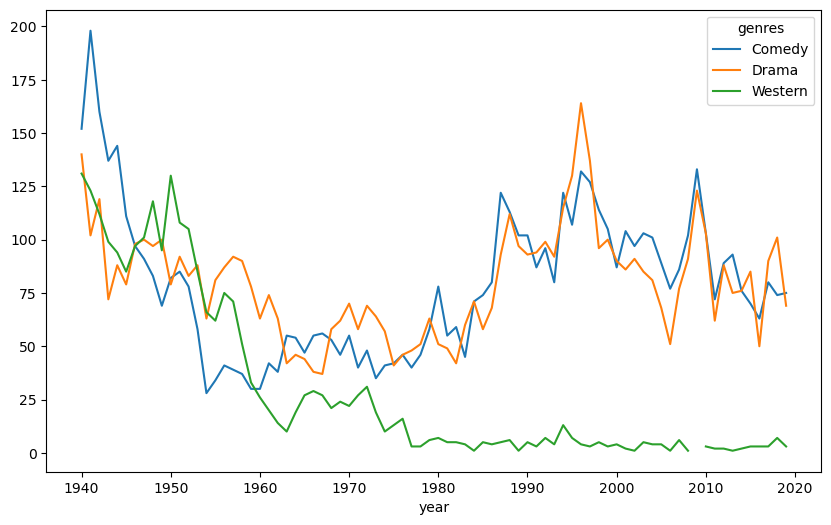

In [26]:
trend_pivot.plot(figsize=(10,6))

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

In [33]:
df['cast']=df['cast'].apply(lambda x: [x] if isinstance(x, str) else x)

all_actors = []

for sublist in df['cast']:
    for actor in sublist:
        all_actors.append(actor)

actor_counts = pd.Series(all_actors).value_counts().reset_index()

actor_counts.columns = ['actor', 'movies_count']

top_10_actors = actor_counts.head(10)

print(top_10_actors)

               actor  movies_count
0   Charles Starrett            99
1  Johnny Mack Brown            92
2  Samuel L. Jackson            87
3     Robert De Niro            86
4     Robert Mitchum            81
5       Bruce Willis            80
6         Glenn Ford            80
7         John Wayne            79
8         Roy Rogers            74
9      Robert Duvall            74


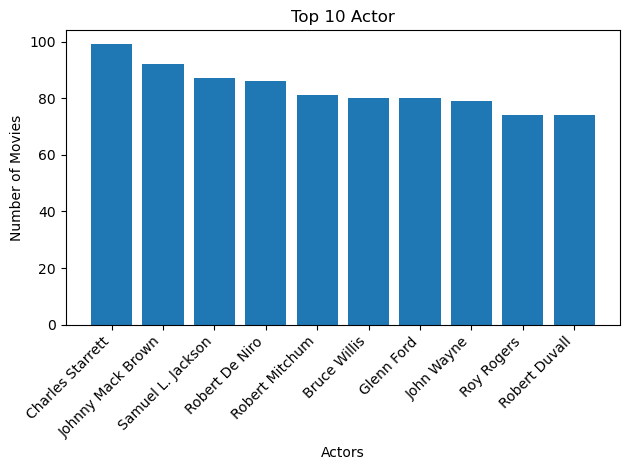

In [32]:
plt.bar(top_10_actors['actor'], top_10_actors['movies_count'])
plt.title('Top 10 Actor')
plt.xlabel('Actors')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [35]:
df['cast'] = df['cast'].apply(lambda x: [x] if isinstance(x, str) else x)

df_exploded_cast = df.explode('cast')

top_actors = df_exploded_cast['cast'].value_counts().head(3).index.tolist()

df_top = df[df['cast'].apply(lambda x: any (actor in x for actor in top_actors))]

df_top

,title,year,cast,genres
20,Bad Man from Red Butte,1940,"[Johnny Mack Brown, Bob Baker, Fuzzy Knight]",[Western]
36,Blazing Six Shooters,1940,"[Charles Starrett, Iris Meredith, Dick Curtis]",[Western]
43,Boss of Bullion City,1940,"[Johnny Mack Brown, Maria Montez, Nell O'Day]",[Western]
55,Bullets for Rustlers,1940,"[Charles Starrett, Lorna Gray, Bob Nolan]",[Western]
112,The Durango Kid,1940,"[Charles Starrett, Luana Walters, Kenneth McDo...",[Western]
...,...,...,...,...
20694,Glass,2019,"[James McAvoy, Bruce Willis, Samuel L. Jackson...",[Superhero]
20718,Captain Marvel,2019,"[Brie Larson, Samuel L. Jackson, Ben Mendelsoh...",[Superhero]
20740,Unicorn Store,2019,"[Brie Larson, Samuel L. Jackson, Joan Cusack, ...","[Comedy, Drama, Fantasy]"
20791,Shaft,2019,"[Samuel L. Jackson, Jessie Usher, Richard Roun...","[Action, Comedy]"


In [39]:
rows = []

for _, row in df_top.iterrows():
    for actor in row ['cast']:
        if actor in top_actors:
            rows.append({'year': row['year'], 'actor':actor})

actors_df = pd.DataFrame(rows)
print(actors_df)

     year              actor
0    1940  Johnny Mack Brown
1    1940   Charles Starrett
2    1940  Johnny Mack Brown
3    1940   Charles Starrett
4    1940   Charles Starrett
..    ...                ...
273  2019  Samuel L. Jackson
274  2019  Samuel L. Jackson
275  2019  Samuel L. Jackson
276  2019  Samuel L. Jackson
277  2019  Samuel L. Jackson

[278 rows x 2 columns]


In [43]:
actor_year_stats = (actors_df.groupby(['actor','year']).size().reset_index(name='movie_count').sort_values(by='year'))

print(actor_year_stats.head())

                actor  year  movie_count
0    Charles Starrett  1940            6
13  Johnny Mack Brown  1940            8
14  Johnny Mack Brown  1941            7
1    Charles Starrett  1941            7
15  Johnny Mack Brown  1942            6


In [47]:
pivot_df = actor_year_stats.pivot(index='year', columns='actor', values='movie_count').fillna(0)

print('Pivot-таблиця:')
print(pivot_df.head(), "\n")

Pivot-таблиця:
actor  Charles Starrett  Johnny Mack Brown  Samuel L. Jackson
year                                                         
1940                6.0                8.0                0.0
1941                7.0                7.0                0.0
1942                8.0                6.0                0.0
1943                6.0                9.0                0.0
1944                5.0                8.0                0.0 



<Axes: xlabel='year'>

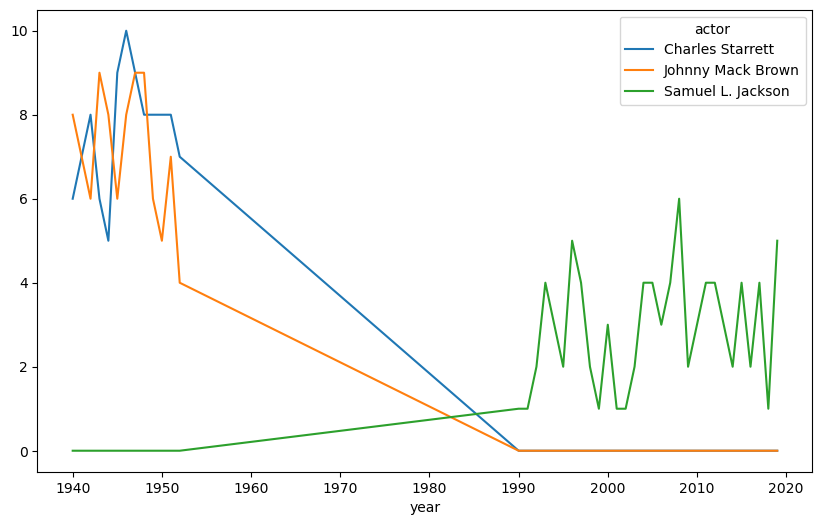

In [48]:
pivot_df.plot(figsize=(10,6))

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.